# Tuning hyperparameters

Set directory

In [6]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

Load data:

In [7]:
from Modules.read_data import read_data

(
    DK1_train, 
    DK1_test, 
    DK2_train, 
    DK2_test,
    DK1_train_weather, 
    DK1_test_weather, 
    DK2_train_weather, 
    DK2_test_weather
    ) = read_data("combined_data_cleaned_v5.csv")

Notebook_dir: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Modules
Python_dir: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode
Data_folder: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Data
Training data shape (DK1): (78900, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78900, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%


## Import model and choose parameter search grid

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from Modules.Load_RF_forecast_models import load_rf_models

# load_rf_models currently supports only the optional timeout argument.
rf_models = load_rf_models()

# Initialize model:
model = RandomForestRegressor()

# Keep at least one number in each list to avoid wrong calculation of total combinations
# If a parameter is not relevant just set a 0 in the list
param_grid = {
    'n_estimators': [50, 200, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 20, 50],
    'min_samples_leaf': [1, 10, 50]
}

num_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total number of combinations to test: {num_combinations}")


Total number of combinations to test: 1


## Choose validation setup


**Setup 1**

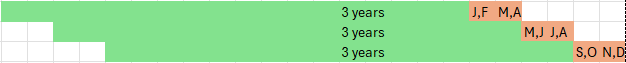

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

## Find best parameters

### Hyperparameter search for DK1:

Remember to give the right path to save the csv with results!

In [9]:
from skforecast.exceptions import IgnoredArgumentWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Raw feature columns are present")
warnings.filterwarnings("ignore", category=UserWarning, message="Some categorized features not in dataset")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

Total number of combinations to test: 1

Combination 1/1: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1}
Model trained. Now validating on 1 folds...

Average RMSE across all weeks in all folds: 361.333

Average MAE across all weeks in all folds: 298.317

Average SMAPE across all weeks in all folds: 72.574


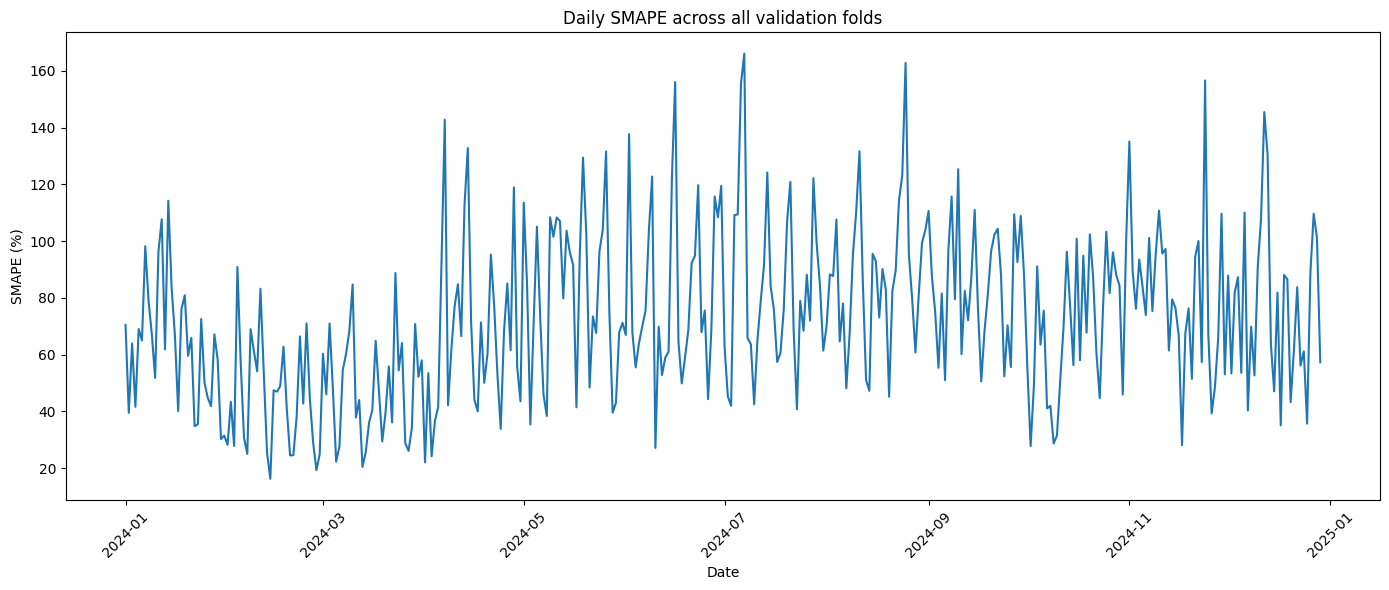


Results saved to: c:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Shallow learners\Random Forest\DK1_final_RF_results_2.csv


In [10]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK1_train,
        dk_zone = "DK1",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        predict_horizon = 52 * 168,     # 168 hours = 1 week
        stride = 1 * 168,              
        use_scaler = False,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly SMAPE values for each fold in each combination?
        plot = True,                   # Plot daily SMAPE values for the entire predict_horizon for each combination?
        rf_models = rf_models
    )

    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Random Forest")
base_filename = "DK1_final_RF_results_2.csv"          # Name the results file
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


### Hyperparameter search for DK2:

Remember to give the right path to save the csv with resutls!

In [ ]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK2_train,
        dk_zone = "DK2",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        predict_horizon = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,
        use_scaler = False,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly SMAPE values for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination?
        rf_models = rf_models
    )

    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "Random Forest")
base_filename = "DK2_hyperparameter_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1
while os.path.exists(filename):
    filename = os.path.join(folder, f"{base_filename}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))
